Computing 6-qubit...
  bw=0.1 | mean entropy=0.2367
  bw=0.2 | mean entropy=0.6741
  bw=0.3 | mean entropy=1.0872
  bw=0.4 | mean entropy=1.3146
  bw=0.5 | mean entropy=1.5546
  bw=0.6 | mean entropy=1.6251
  bw=0.7 | mean entropy=1.7053
  bw=0.8 | mean entropy=1.6995
  bw=0.9 | mean entropy=1.6883
  bw=1.0 | mean entropy=1.6789
Computing 8-qubit...
  bw=0.1 | mean entropy=0.2065
  bw=0.2 | mean entropy=0.5985
  bw=0.3 | mean entropy=0.9793
  bw=0.4 | mean entropy=1.3728
  bw=0.5 | mean entropy=1.5650
  bw=0.6 | mean entropy=1.7515
  bw=0.7 | mean entropy=1.9213
  bw=0.8 | mean entropy=2.0160
  bw=0.9 | mean entropy=2.0844
  bw=1.0 | mean entropy=2.1658
Computing 12-qubit...
  bw=0.1 | mean entropy=0.1500
  bw=0.2 | mean entropy=0.4446
  bw=0.3 | mean entropy=0.7899
  bw=0.4 | mean entropy=1.0371
  bw=0.5 | mean entropy=1.2970
  bw=0.6 | mean entropy=1.5324
  bw=0.7 | mean entropy=1.6285
  bw=0.8 | mean entropy=1.7058
  bw=0.9 | mean entropy=1.7036
  bw=1.0 | mean entropy=1.7893


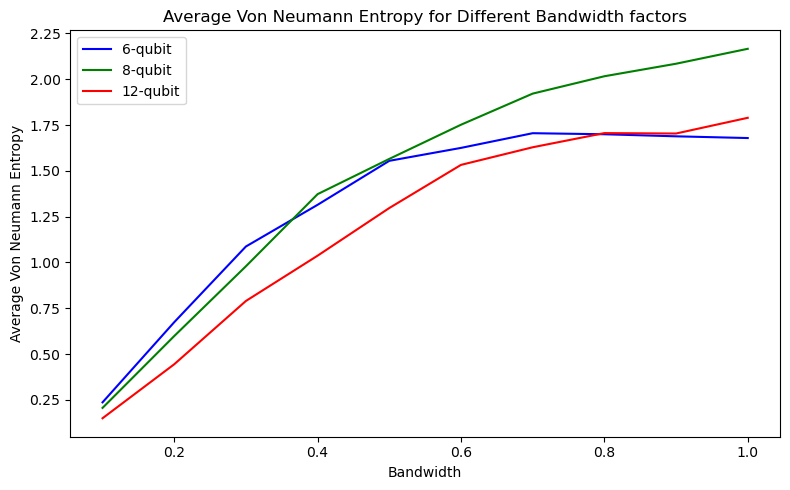

Fig 6 saved as fig6.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import DensityMatrix, partial_trace, entropy
from qiskit_aer import AerSimulator
def make_6q_pqc():
    x = ParameterVector("x", 24)
    qc = QuantumCircuit(6)
    idx = 0
    for q in range(6):
        qc.rx(x[idx], q)
        idx += 1
    for q in range(6):
        qc.ry(x[idx], q)
        idx += 1
    for q in range(5):
        qc.cz(q, q+1)
    qc.cz(5, 0)
    for q in range(6):
        qc.rx(x[idx], q)
        idx += 1
    for q in range(6):
        qc.ry(x[idx], q)
        idx += 1
    for q in range(5):
        qc.cx(q, q+1)
    qc.cx(5, 0)
    return qc
def make_8q_pqc():
    x = ParameterVector("x", 24)
    qc = QuantumCircuit(8)
    idx = 0
    for q in range(8):
        qc.rx(x[idx], q)
        idx += 1
    for q in range(8):
        qc.ry(x[idx], q)
        idx += 1
    for q in range(7):
        qc.cz(q, q+1)
    qc.cz(7, 0)
    for q in range(8):
        qc.rx(x[idx], q)
        idx += 1
    for q in range(7):
        qc.cx(q, q+1)
    qc.cx(7, 0)
    return qc
def make_12q_pqc():
    x = ParameterVector("x", 24)
    qc = QuantumCircuit(12)
    idx = 0
    for q in range(12):
        qc.rx(x[idx], q)
        idx += 1
    for q in range(11):
        qc.cz(q, q+1)
    qc.cz(11, 0)
    for q in range(12):
        qc.ry(x[idx], q)
        idx += 1
    for q in range(11):
        qc.cx(q, q+1)
    qc.cx(11, 0)
    return qc
pqc_fns = [make_6q_pqc, make_8q_pqc, make_12q_pqc]
qubit_counts = [6, 8, 12]
qubit_labels = ['6-qubit', '8-qubit', '12-qubit']
colors = ['blue', 'green', 'red']
bandwidth_values = np.arange(0.1, 1.1, 0.1)
n_repeats = 20
sim = AerSimulator()
entropy_results = {label: [] for label in qubit_labels}
for pqc_fn, n_qubits, label in zip(pqc_fns, qubit_counts, qubit_labels):
    print(f"Computing {label}...")
    for bw in bandwidth_values:
        entropies = []
        pqc = pqc_fn()
        for _ in range(n_repeats):
            params = np.random.uniform(0, 1, 24) * bw
            param_dict = dict(zip(pqc.parameters, params))
            bound = pqc.assign_parameters(param_dict)
            bound.save_statevector()
            bound_t = transpile(bound, sim)
            result = sim.run(bound_t).result()
            sv = result.get_statevector()
            dm = DensityMatrix(sv)
            half = n_qubits // 2
            traced = partial_trace(dm, list(range(half, n_qubits)))
            ent = entropy(traced, base=2)
            entropies.append(float(ent))
        entropy_results[label].append(np.mean(entropies))
        print(f"  bw={bw:.1f} | mean entropy={np.mean(entropies):.4f}", flush=True)
plt.figure(figsize=(8, 5))
for label, color in zip(qubit_labels, colors):
    plt.plot(bandwidth_values, entropy_results[label], label=label, color=color)
plt.xlabel("Bandwidth")
plt.ylabel("Average Von Neumann Entropy")
plt.title("Average Von Neumann Entropy for Different Bandwidth factors")
plt.legend()
plt.tight_layout()
plt.savefig("fig6.png", dpi=150)
plt.show()
print("Fig 6 saved as fig6.png")